## Project 2 

## Exploratory Data Analysis

In [1]:
# import libraries

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset

df =pd.read_csv(r"C:\Users\HP\Documents\Dataset for Data Analytics.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
#  check the sturcture of the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [4]:
# check for the shape and features of the data 

df.shape

(1200, 14)

In [5]:
# check for missing value

df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [6]:
# drop the missing values in the couponcode column

df= df.dropna(subset = ['CouponCode'])

## Features Engineering

In [7]:
# convert to date time for extraction
df['Date'] = pd.to_datetime(df['Date'])

# Create the Day of the week from Date column
df['DayOfWeek'] = df['Date'].dt.day_name()

# Create for month
df['Month'] = df['Date'].dt.month_name()

# create for year
df['Year'] = df['Date'].dt.year.astype(str)

# Convert back to normal date format after extraction
df['Date'] = df['Date'].dt.strftime('%Y/%m/%d')

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,DayOfWeek,Month,Year
0,ORD200000,2023/01/04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,Wednesday,January,2023
1,ORD200001,2024/08/23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,Friday,August,2024
2,ORD200002,2024/02/27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,Tuesday,February,2024
3,ORD200003,2023/10/15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,Sunday,October,2023
4,ORD200004,2025/05/08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,Thursday,May,2025


In [8]:
# Check the shape and features

df.shape

(891, 17)

After feature engineering there are now 891 rows and 17 columns

In [9]:
# Check the summary Statistics

df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,891.000000,891.000000,891.000000,891.000000
mean,2.911336,360.596835,5.459035,1057.643715
std,1.414212,196.752386,2.277209,822.703899
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,189.345000,4.000000,415.785000
50%,3.000000,371.290000,5.000000,819.500000
75%,4.000000,526.445000,7.000000,1581.135000
max,5.000000,699.930000,10.000000,3456.400000


## Univariate Analysis for Numerical Variables¶

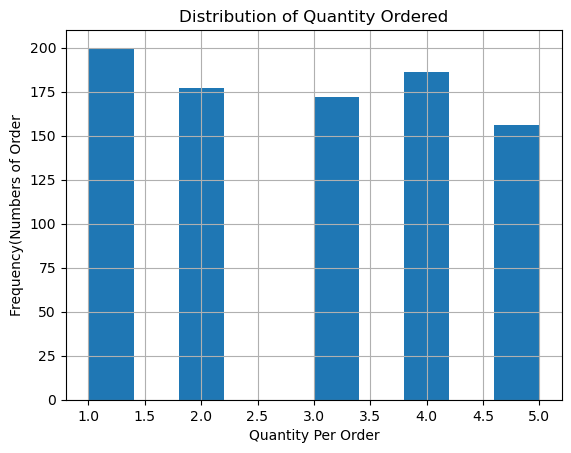

In [10]:
# distribution of quantity across the data

df['Quantity'].hist()
plt.title('Distribution of Quantity Ordered')
plt.xlabel('Quantity Per Order')
plt.ylabel('Frequency(Numbers of Order')
plt.show()

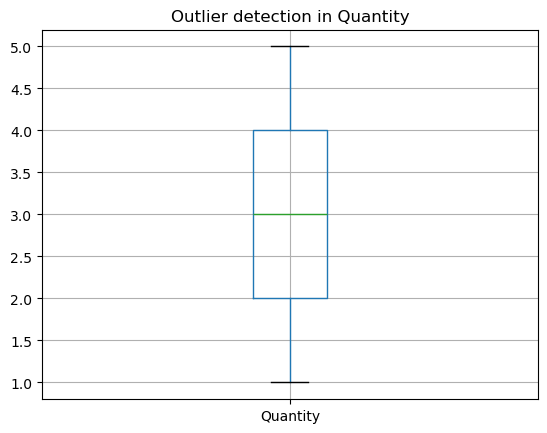

In [11]:
# Detect outlier in the quantity column

df.boxplot(column ='Quantity')
plt.title('Outlier detection in Quantity')
plt.show()

The Histogram showed that the quantity is evenly distribution across the data suggest no dominant in the order size, indicating that there is a specialized product catalog where customer typically buy similar quantities.

The box plot shows that there are not outliers in the quantity ordered across the data

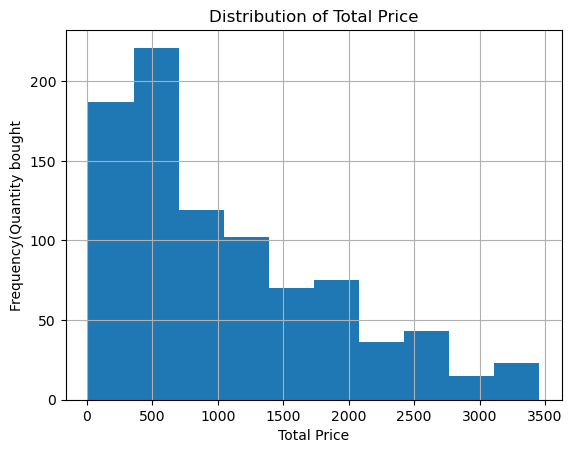

In [12]:
# distribution of Total price across the data

df['TotalPrice'].hist()
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency(Quantity bought')
plt.show()

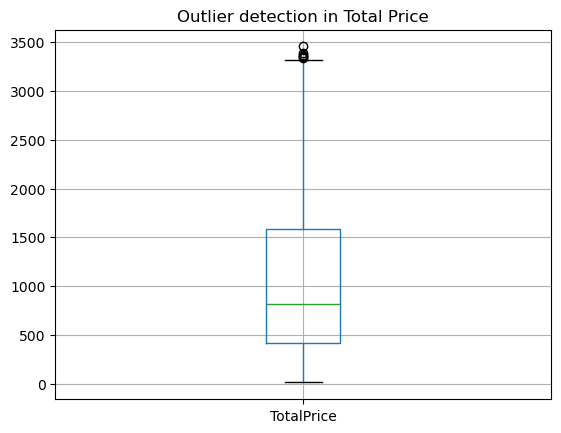

In [13]:
# detect outlier

df.boxplot(column ='TotalPrice')
plt.title('Outlier detection in Total Price')
plt.show()

The histogram is right skewed which reveals that there is an inverse relationship between the ordered quantity and the total price. Quantities with higher orders tend to have lower total price while quantities with fewer orders tend to have higher total price. This suggest that the product with low cost are purchased in bulk while the product with high cost are purchased in samaller quantity.

The box plot reveals that there are outliers in the total price

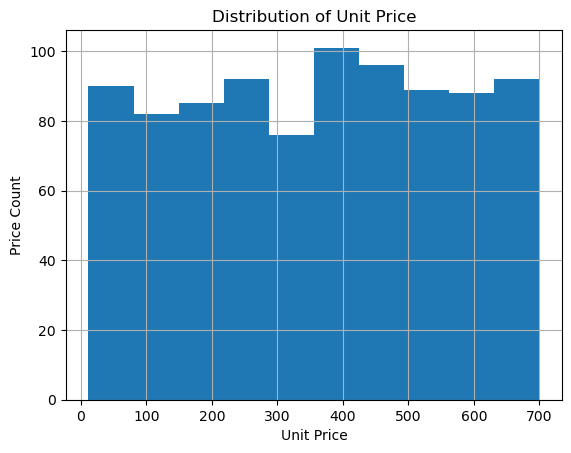

In [15]:
# distribution of unit price across the data

df['UnitPrice'].hist()
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Price Count')
plt.show()

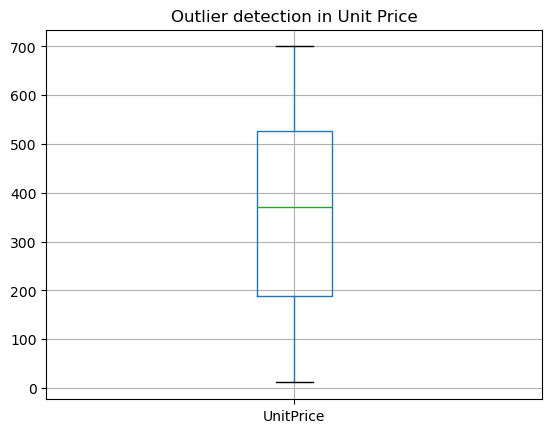

In [16]:
df.boxplot(column ='UnitPrice')
plt.title('Outlier detection in Unit Price')
plt.show()

The histogram reveals that the unit price is uniformly distributed across the data showing no dominant in the price like no too expensive product and  cheaper product. There are no outlier in the unit price

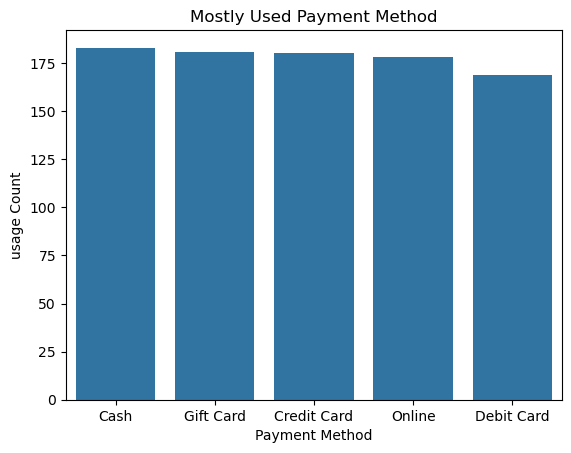

In [17]:
# Which Payment Method is mostly used

top_payment = df['PaymentMethod'].value_counts()
sns.barplot(x=top_payment.index, y=top_payment.values)
plt.title('Mostly Used Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('usage Count')
plt.show()

The chart reveals that there is no significant difference between the payment method, all payment method are used equally by the customers

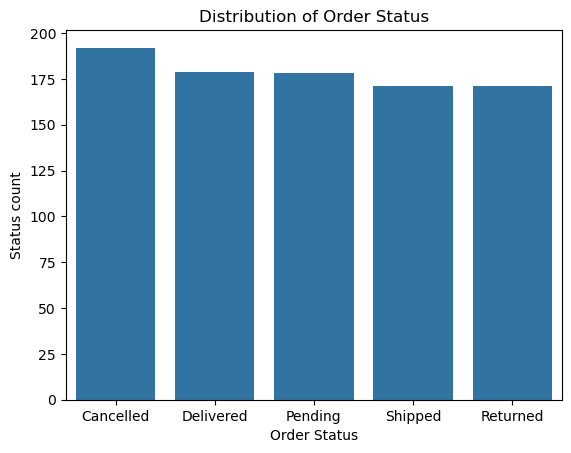

In [18]:
# Check the top order status

top_order = df['OrderStatus'].value_counts()
sns.barplot(x=top_order.index, y=top_order.values)
plt.title('Distribution of Order Status')
plt.xlabel('Order Status')
plt.ylabel('Status count')
plt.show()

The chart shows a uniform distribution across the data with cancellation rate slightly greater compared to quantity delivered and shipped, while the return rate is the same as the quantity delivered and shipped. Suggesting that there is either low quality delivered leading to return of product or not enough product in stock leading to high cancellation.

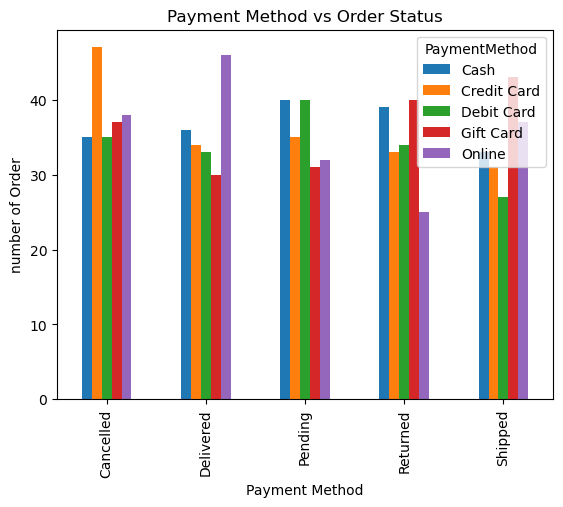

In [19]:
# Does payment method affect cancellation rate

canceled_payment = pd.crosstab(df['OrderStatus'], df['PaymentMethod'])
canceled_payment.plot(kind ='bar')
plt.title('Payment Method vs Order Status')
plt.xlabel('Payment Method')
plt.ylabel('number of Order')
plt.show()

The bar chart reveals that credit card get cancelled more, online gets delivered more, gift card gets shipped more while return and pending perform similarly this indicate that there might be difficulty in using the credit or dissatisfication on the payment method

In [20]:
# Arrange the month order

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']

# convert month to categorical 
df['Month'] =pd.Categorical(df['Month'], categories = month_order, ordered = True)

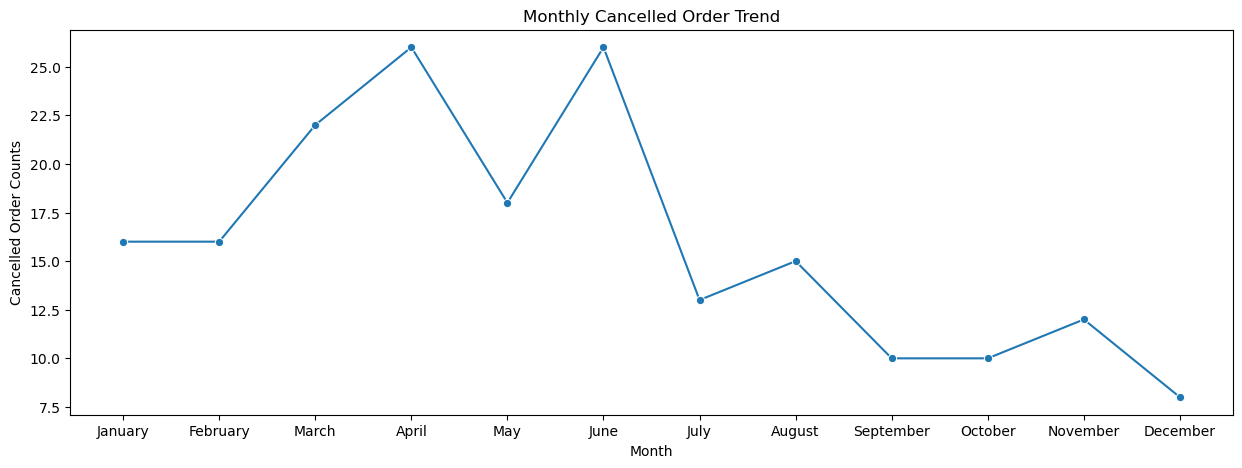

In [21]:
# How many orders are been cancelled per month

cancelled = df[df['OrderStatus'] == 'Cancelled'].groupby('Month', observed=True).size()
plt.figure(figsize=(15,5))
sns.lineplot(x=cancelled.index, y=cancelled.values, marker='o')
plt.title('Monthly Cancelled Order Trend')
plt.xlabel('Month')
plt.ylabel('Cancelled Order Counts')
plt.show()

The Chart reveals that cancellation is generally high in the first half and stable in the second half. April is the highhest peak where 25 ordeers were cancelled while the lowest is in December. This suggests that investigation should be carried out on Spring Operation to know why there are lots of cancelled order that is between April and June.

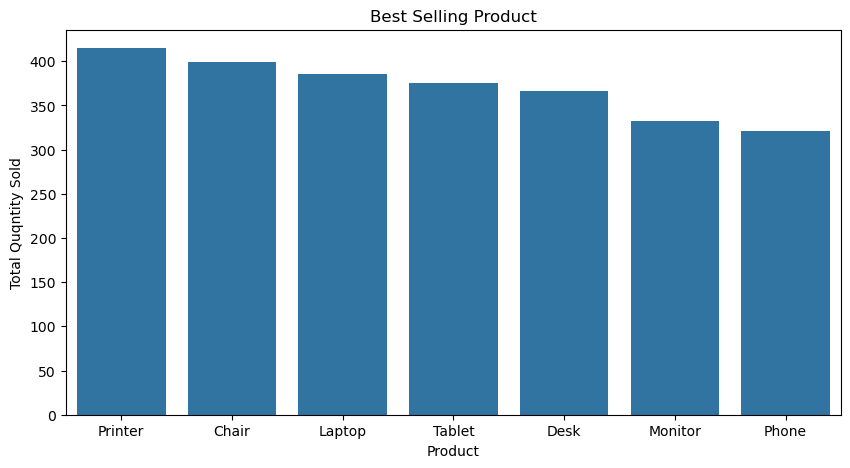

In [22]:
# find the Best Selling Product

best_product = df.groupby('Product')['Quantity'].sum().sort_values(ascending =False)

# Plot the virtual
plt.figure(figsize=(10,5))
sns.barplot( x=best_product.index, y= best_product.values)
plt.title('Best Selling Product')
plt.xlabel('Product')
plt.ylabel('Total Quqntity Sold')
plt.show()

The chart reveals that there is no best selling product, this is because all the product are bought in a similar quantity and performs relatively in the same way.

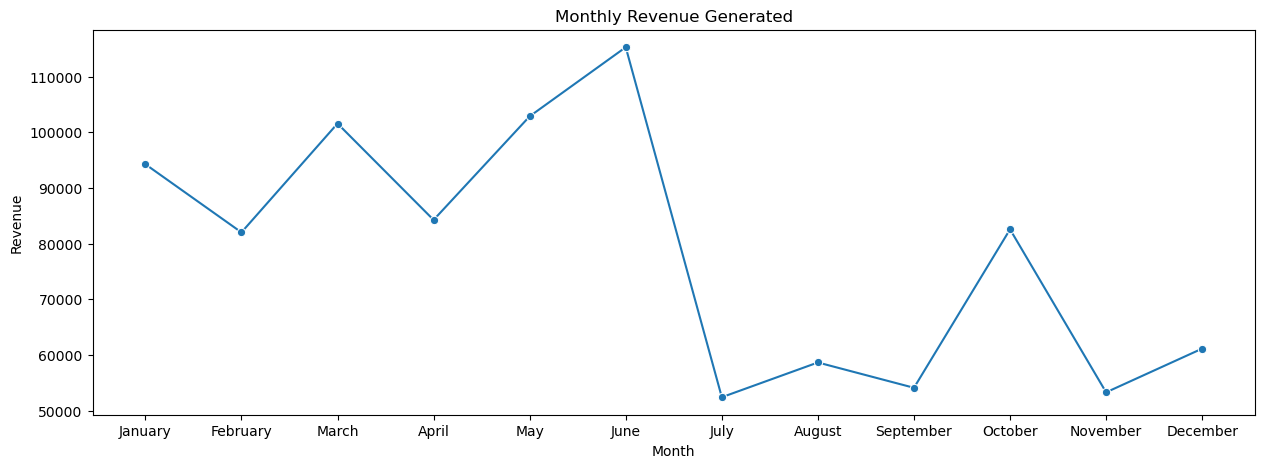

In [23]:
# Check the Month with the Highest Revenue

revenue_per_month= (df.groupby('Month', observed=True)['TotalPrice'].sum())

plt.figure(figsize=(15,5))
sns.lineplot(x= revenue_per_month.index, y= revenue_per_month.values, marker='o')
plt.title('Monthly Revenue Generated')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

The chart shows that June is the best performing month and it generated the total od 110,000 at the peak level while the worse performing months are July, November and September the sales dropped to about 50,000, the other months also performed higher. this suggest that the first half of the year is when the business appears to be heavy and gradually crashes in the second half.

I will suggests that since the first half business appears to sell more, there should more stock or product for sales.

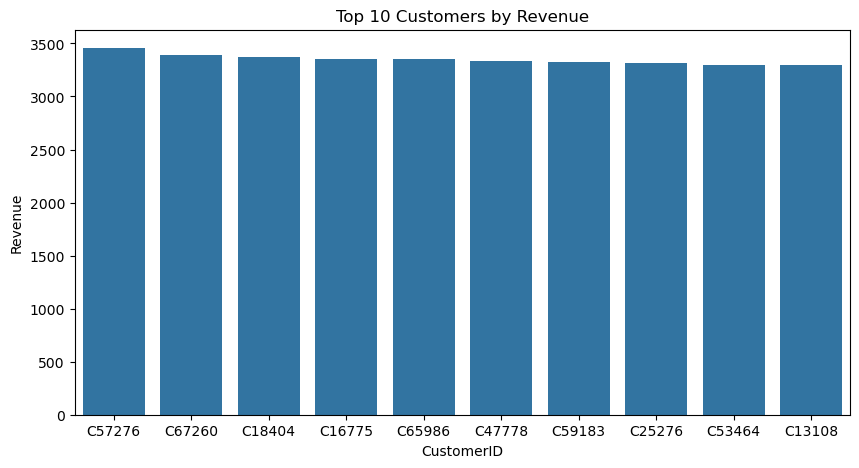

In [24]:
# Find the customer that generates the highest revenue

top_customers = (df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending = False).head(10))

plt.figure(figsize=(10,5))
sns.barplot(x= top_customers.index, y= top_customers.values)
plt.title('Top 10 Customers by Revenue')
plt.xlabel('CustomerID')
plt.ylabel('Revenue')
plt.show()

The chart shows that the top 10 customers generated relatively or similar revenue

In [25]:
# Top 5 customers over the years
top_customer = (df.groupby(['Year', 'CustomerID'])['TotalPrice'].sum().reset_index())

top5 = (
    top_customer
    .sort_values(['Year', 'TotalPrice'], ascending=[False, True])
    .groupby('Year')
    .head(5)
)

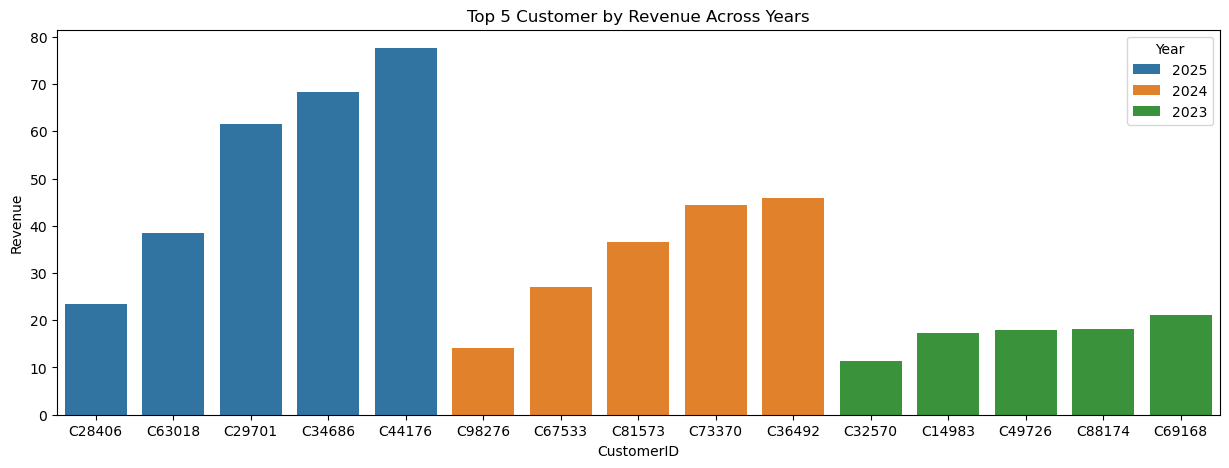

In [26]:
# Plotting the visual

plt.figure(figsize=(15,5))
sns.barplot(x ='CustomerID', y = 'TotalPrice', hue='Year', data=top5)
plt.title('Top 5 Customer by Revenue Across Years')
plt.xlabel('CustomerID')
plt.ylabel('Revenue')
plt.show()

The chart shows that 2025 has the highest customer count, 2024 has medium count while 2023 has the least, however there is no returning customer across the year. I suggest that at the end of each year, the 5 top customers should be given incentive to make them a loyal customer to the business.

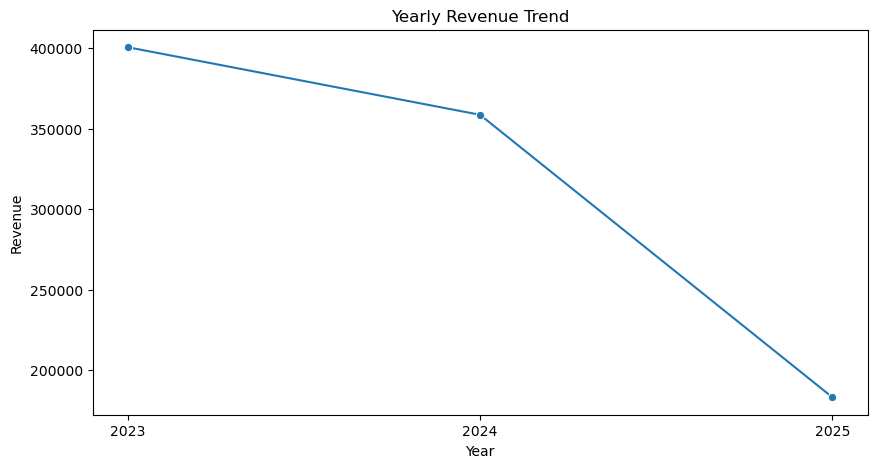

In [27]:
# which Year has the highest Revenue

yearly_trend= (df.groupby('Year')['TotalPrice'].sum())
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, marker='o')
plt.title('Yearly Revenue Trend')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.show()

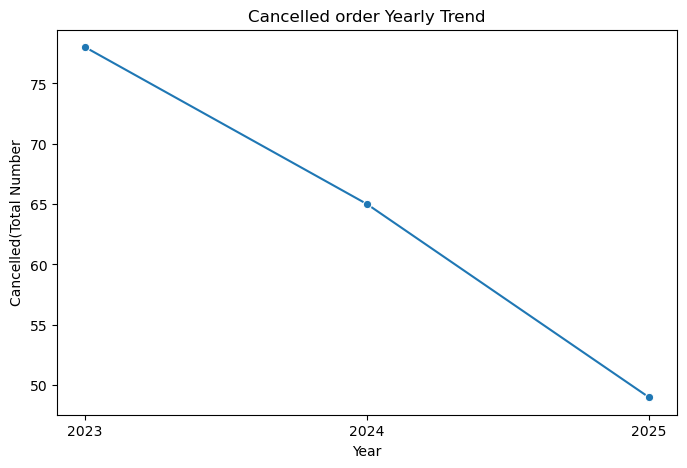

In [28]:
# Which Year got the Highest cancelled orders

yearly_cancelled = df[df['OrderStatus']=='Cancelled'].groupby('Year').size()
plt.figure(figsize=(8,5))
sns.lineplot(x=yearly_cancelled.index, y=yearly_cancelled.values, marker='o')
plt.title('Cancelled order Yearly Trend')
plt.xlabel('Year')
plt.ylabel('Cancelled(Total Number')
plt.show()

The Yearly Revenue Trend shows that 2023 generated the highest revenue of 400,000, in 2024 the revenue dropped to 350,000 while in 2025 the revenue dropped drastically. the Yearly cancelled Order Trend shows that in 2023 there was a high rate of cancelling orders at about 75-80, in 2024 there was a rapid drop in order cancellation to about 60-65, while in 2025 there was a drastic drop the the cancellation rate.

since 2025 has the lowest cancellation rate and also has the lowest revenue generation, this suggest that the business is gradually shrinking in the overall performance. It can be that fewer orders are being placed which leads to lower revenue (income) and few cancellations.

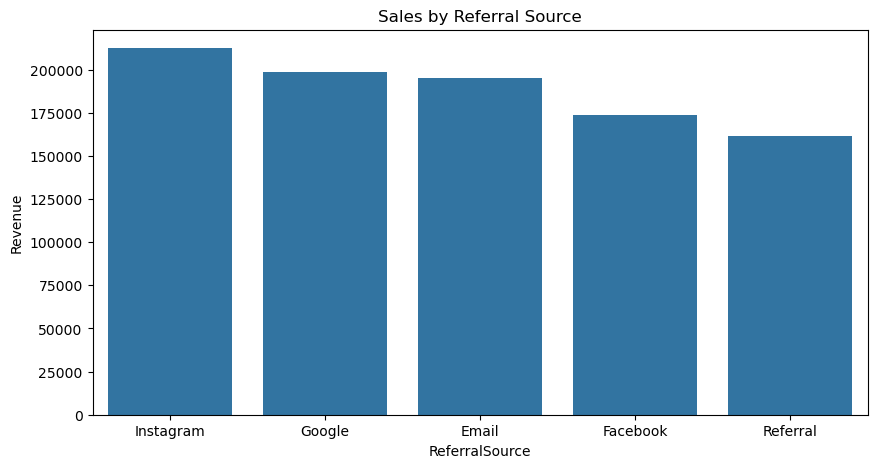

In [29]:
# Which Referral Source generate more sales

referral_source = (df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False))
plt.figure(figsize=(10,5))
sns.barplot(x=referral_source.index, y=referral_source.values)
plt.title('Sales by Referral Source')
plt.xlabel('ReferralSource')
plt.ylabel('Revenue')
plt.show()

The chart reveal that Instagram has the highest referral source and also generate more revenue, Google and Email perform similarly, while Facebook perform slightly higher than the Referral (friend or family referral). This suggest that promotional ads should created to attract more customers.

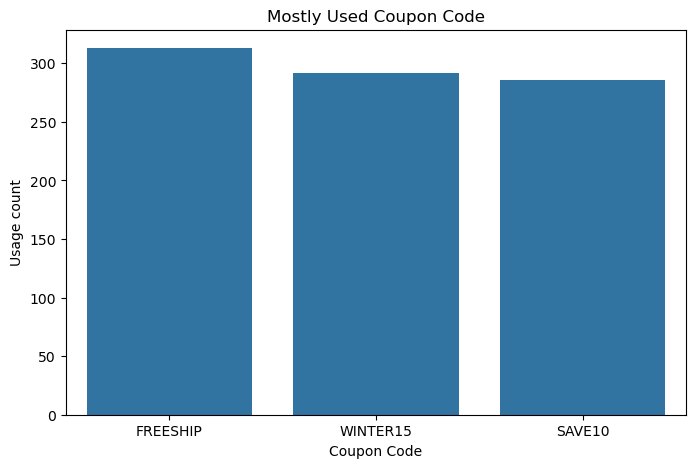

In [30]:
# Which Coupon Code was mostly used

coupon_used = df['CouponCode'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=coupon_used.index, y=coupon_used.values)
plt.title('Mostly Used Coupon Code')
plt.xlabel('Coupon Code')
plt.ylabel('Usage count')
plt.show()

The bar chart shows that FREESHIP coupon code is mostly used compared to the WINTER15 and SAVE10. This suggests that customers are more motivated to use the free shipping coupon than the fixed amount counts. The discount coupon of WINTER15 and SAVE10 perform similarly, this implies that the specific type of discount matter less if discount exist or not.

In [31]:
# Correlation Analysis

corr = df.corr(numeric_only=True)
corr

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.028155,0.644847,0.634515
UnitPrice,0.028155,1.000000,0.021396,0.709612
ItemsInCart,0.644847,0.021396,1.000000,0.413954
TotalPrice,0.634515,0.709612,0.413954,1.000000


<Axes: >

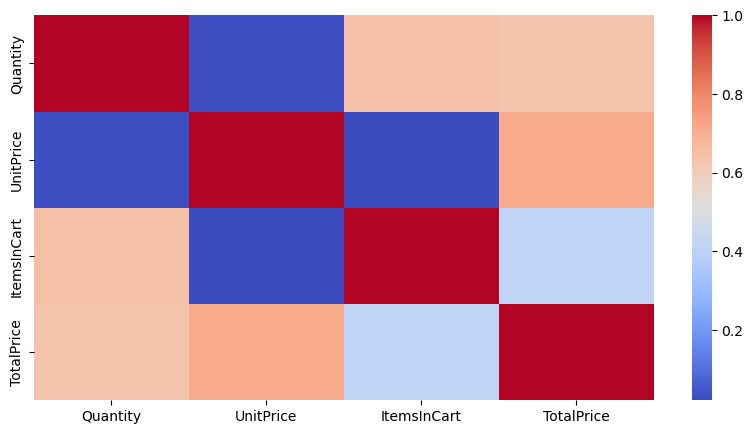

In [32]:
# Find the correlation between the Numerical variables using the heatmap

plt.figure(figsize=(10,5))
sns.heatmap(corr, cmap='coolwarm')

The correlation Analysis shows that there is a strong positive correlation of 0.71 between the unit price and the total price that the more the uni price increase, the more the total price also increase. suggesting that revenue is highly sensitive to the price of individual products. 
Total price and quantity also has a strong positive correlation of 0.63, that is the more quantity bought, the higher the revenue. Quantity and Items in Cart have a strong correlation of 0.64, that means the more items in cart the more quantity purchased.There is a moderate positive correlation of 0.41 between items in cart and total price suggesting that items in cart does not relative affect revenue while the is a negligible or no correlation between unit price and quantity ordered.